# Anime Recommendation System — Exploratory Data Analysis

This notebook explores the **Anime Recommendations Database** (anime.csv, rating.csv)
before any model building: missing values, duplicates, rating distributions,
genre distributions, popularity, and user activity patterns.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import build_clean_dataset, basic_eda_stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load & Clean Data

In [2]:
data = build_clean_dataset()
anime, ratings, ratings_explicit = data.anime, data.ratings, data.ratings_explicit
print("Anime shape:", anime.shape)
print("Ratings shape:", ratings.shape)
print("Explicit ratings shape:", ratings_explicit.shape)
anime.head()

2026-06-20 18:19:09,963 | INFO | Loading raw CSV files...


2026-06-20 18:19:09,977 | INFO | anime.csv shape: (60, 7) | rating.csv shape: (12677, 3)


2026-06-20 18:19:09,980 | INFO | Removed 0 duplicate anime rows.


2026-06-20 18:19:09,985 | INFO | Cleaned anime shape: (60, 7)


2026-06-20 18:19:09,991 | INFO | Removed 0 duplicate rating rows.


2026-06-20 18:19:09,993 | INFO | Cleaned ratings shape: (12677, 3)


Anime shape: (60, 7)
Ratings shape: (12677, 3)
Explicit ratings shape: (11709, 3)


,anime_id,name,genre,type,episodes,rating,members
0,1,Attack on Titan,"Action, Drama, Horror, Slice of Life",Movie,1,7.95,18402
1,2,Vinland Saga,"Comedy, Drama, School, Supernatural",TV,1,8.08,159522
2,3,Death Note,"Romance, Slice of Life",ONA,148,7.29,16246
3,4,Fullmetal Alchemist: Brotherhood,"Romance, School",ONA,50,8.92,59734
4,5,Naruto,"Shounen, Sports",OVA,1,7.08,44592


## 2. Missing Values & Duplicates
Missing values and duplicates are already handled inside `preprocessing.build_clean_dataset()`.
Below we confirm the cleaned tables are free of nulls in the key columns.

In [3]:
print("Anime null counts:\n", anime.isnull().sum())
print("\nRatings null counts:\n", ratings.isnull().sum())

Anime null counts:
 anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

Ratings null counts:
 user_id     0
anime_id    0
rating      0
dtype: int64


## 3. Summary Statistics

In [4]:
stats = basic_eda_stats(data)
for k, v in stats.items():
    print(f"{k}: {v}")

n_anime: 60
n_users: 500
n_ratings_total: 12677
n_ratings_explicit: 11709
pct_unrated_watch: 7.64
avg_rating_explicit: 7.37
median_episodes: 18.5
n_unique_genres: 21
type_distribution: {'Movie': 16, 'ONA': 15, 'TV': 13, 'OVA': 8, 'Special': 8}


## 4. Rating Distribution

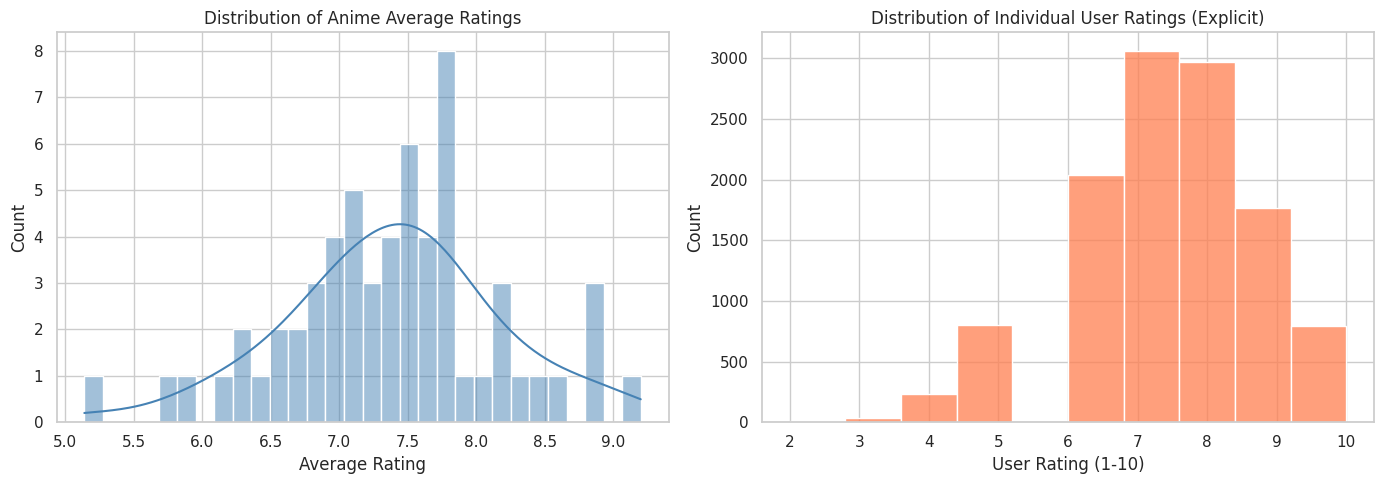

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(anime["rating"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Anime Average Ratings")
axes[0].set_xlabel("Average Rating")

sns.histplot(ratings_explicit["rating"], bins=10, kde=False, ax=axes[1], color="coral")
axes[1].set_title("Distribution of Individual User Ratings (Explicit)")
axes[1].set_xlabel("User Rating (1-10)")
plt.tight_layout()
plt.savefig("../reports/rating_distributions.png", dpi=150)
plt.show()

## 5. Genre Distribution

/tmp/ipykernel_713/769468987.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")


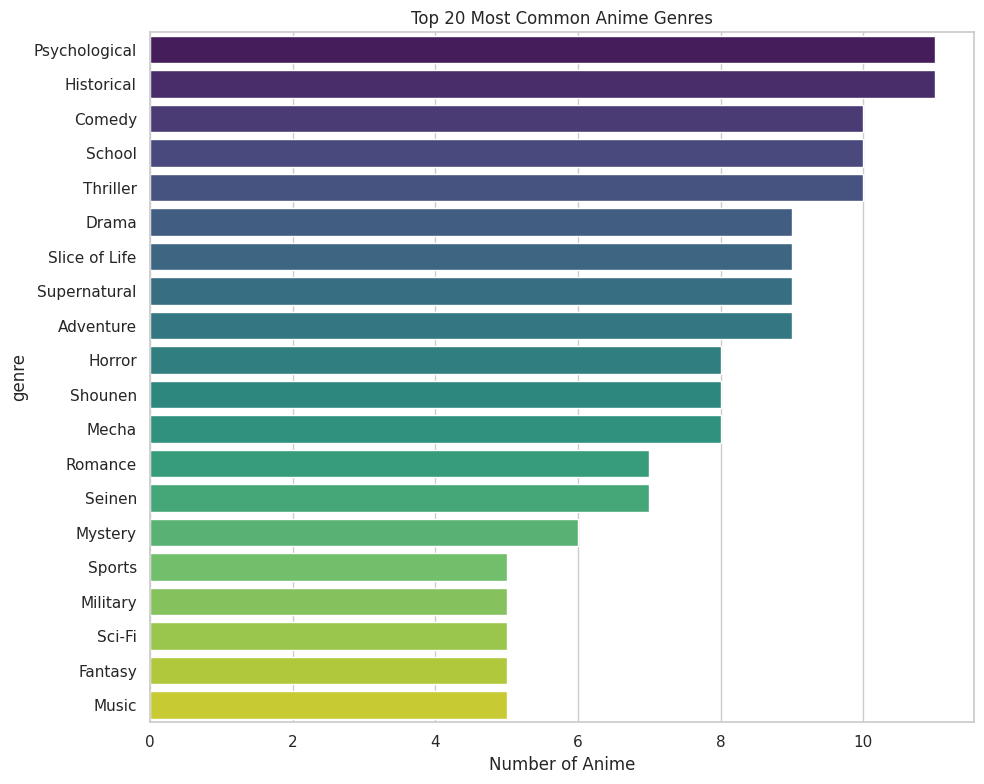

In [6]:
genre_series = anime["genre"].dropna().str.split(", ").explode()
genre_counts = genre_series.value_counts().head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")
plt.title("Top 20 Most Common Anime Genres")
plt.xlabel("Number of Anime")
plt.tight_layout()
plt.savefig("../reports/genre_distribution.png", dpi=150)
plt.show()

## 6. Most Popular Anime (by Members)

/tmp/ipykernel_713/1301681113.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="members", y="name", data=most_popular, palette="mako")


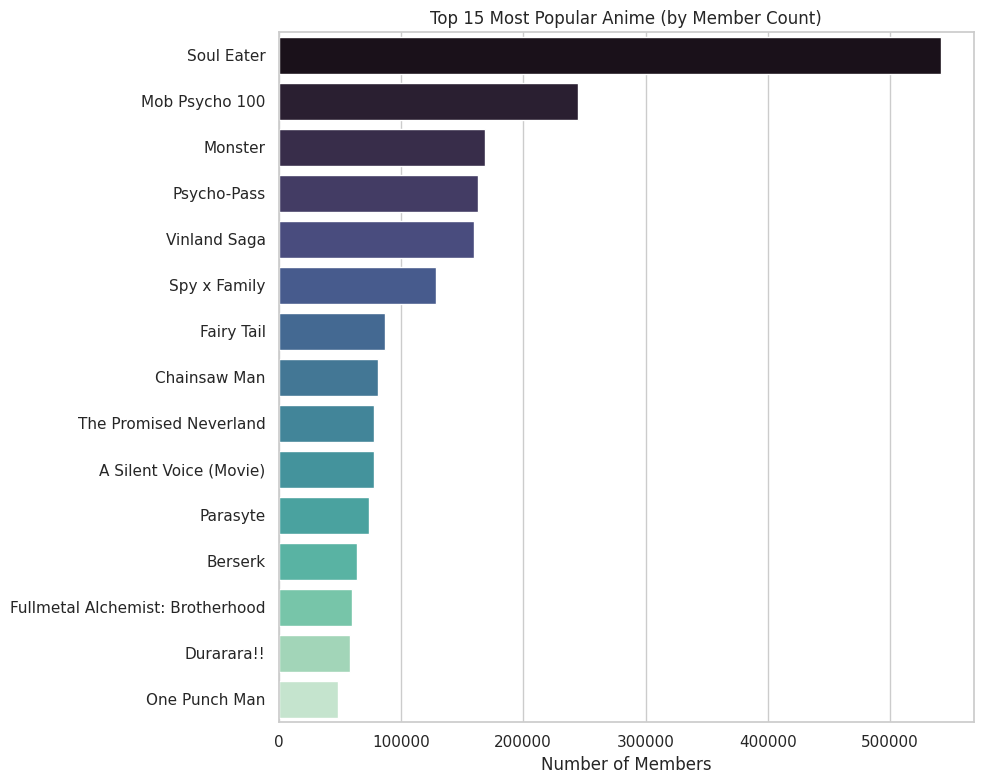

In [7]:
most_popular = anime.sort_values("members", ascending=False).head(15)
plt.figure(figsize=(10, 8))
sns.barplot(x="members", y="name", data=most_popular, palette="mako")
plt.title("Top 15 Most Popular Anime (by Member Count)")
plt.xlabel("Number of Members")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../reports/most_popular_anime.png", dpi=150)
plt.show()

## 7. Highest Rated Anime (min member threshold to avoid noise)

/tmp/ipykernel_713/842600212.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rating", y="name", data=highest_rated, palette="rocket")


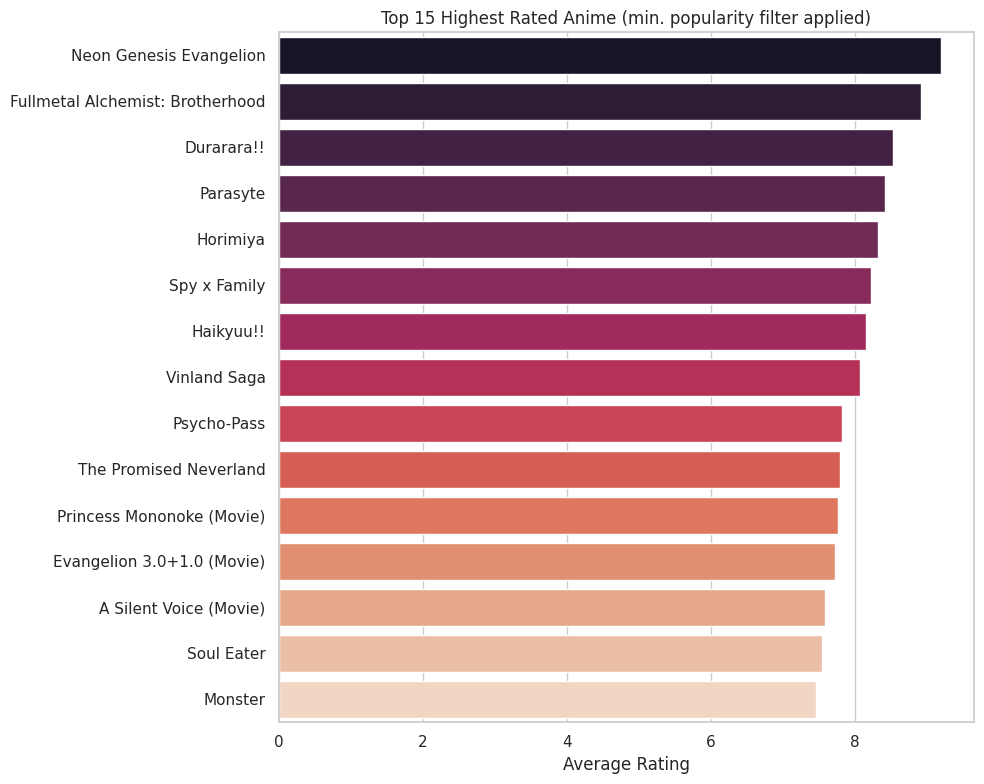

In [8]:
member_threshold = anime["members"].quantile(0.5)
highest_rated = anime[anime["members"] >= member_threshold].sort_values("rating", ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x="rating", y="name", data=highest_rated, palette="rocket")
plt.title("Top 15 Highest Rated Anime (min. popularity filter applied)")
plt.xlabel("Average Rating")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../reports/highest_rated_anime.png", dpi=150)
plt.show()

## 8. Anime Type Distribution

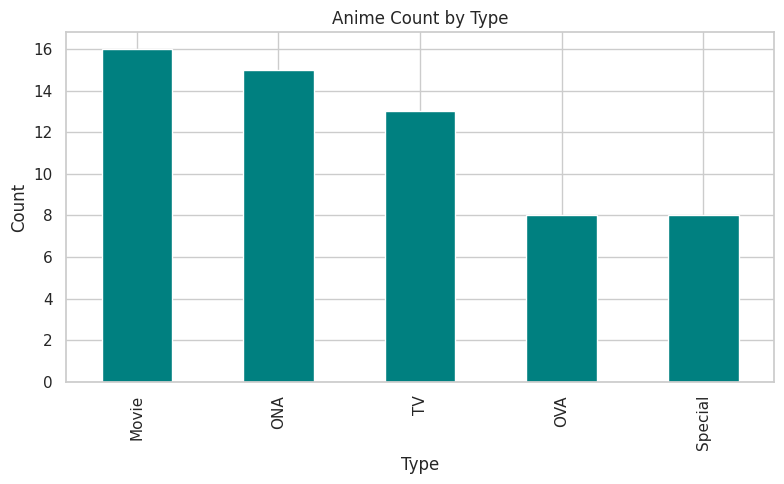

In [9]:
plt.figure(figsize=(8, 5))
anime["type"].value_counts().plot(kind="bar", color="teal")
plt.title("Anime Count by Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/type_distribution.png", dpi=150)
plt.show()

## 9. User Activity Analysis

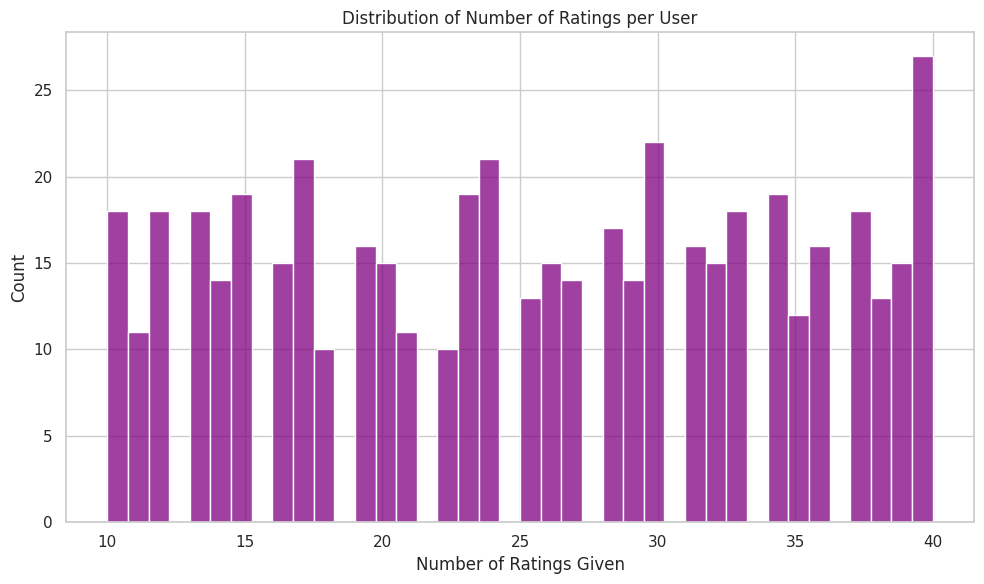

Median ratings per user: 26.0
Max ratings by a single user: 40
Users with only 1 rating: 0


In [10]:
user_activity = ratings.groupby("user_id").size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.histplot(user_activity, bins=40, color="purple")
plt.title("Distribution of Number of Ratings per User")
plt.xlabel("Number of Ratings Given")
plt.tight_layout()
plt.savefig("../reports/user_activity_distribution.png", dpi=150)
plt.show()

print("Median ratings per user:", user_activity.median())
print("Max ratings by a single user:", user_activity.max())
print("Users with only 1 rating:", (user_activity == 1).sum())

## 10. Rating vs. Popularity (Members) Correlation

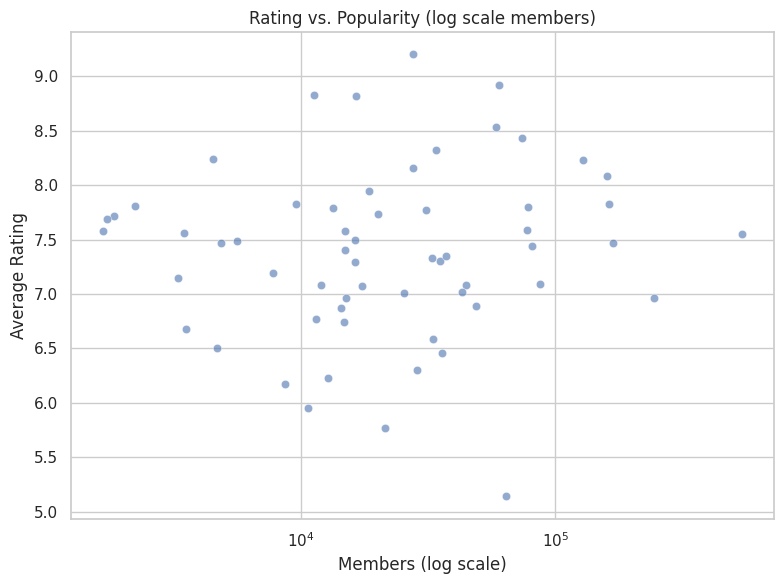

Correlation (rating, members): 0.0840047242143789


In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="members", y="rating", data=anime, alpha=0.6)
plt.xscale("log")
plt.title("Rating vs. Popularity (log scale members)")
plt.xlabel("Members (log scale)")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.savefig("../reports/rating_vs_popularity.png", dpi=150)
plt.show()

print("Correlation (rating, members):", anime["rating"].corr(anime["members"]))

## Key Takeaways
- Most anime ratings cluster in the 6.5–8.5 range; the tail of very high ratings
  belongs to long-running, high-member-count titles.
- Action, Comedy, and Drama dominate genre frequency.
- Popularity (members) and rating are positively but weakly correlated — meaning
  pure popularity-based recommendations alone are not a substitute for personalization.
- User activity is highly skewed: a small fraction of users contribute a
  disproportionate share of ratings (classic long-tail behavior), reinforcing the
  need for collaborative + content hybrid approaches to handle sparse users well.